<a href="https://colab.research.google.com/github/bismarxx/Machine-Learning-I-Actividad-5/blob/main/c.%20rf_vs_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌲 Random Forest vs ⚡ XGBoost
## Comparación de Eficiencia en Clasificación

En este notebook vamos a:
1. Preparar y explorar un dataset de clasificación real
2. Entrenar y optimizar un **Random Forest**
3. Entrenar y optimizar un **XGBoost**
4. Comparar ambos en métricas, curvas de aprendizaje, importancia de features y tiempo de entrenamiento
5. Determinar cuál es el mejor modelo

---

### Diferencia clave entre ambos

```
RANDOM FOREST (Bagging)          XGBoost (Boosting)
────────────────────────         ────────────────────────
Dataset ──► Bootstrap 1 ──► Árbol 1 ─┐
        ──► Bootstrap 2 ──► Árbol 2 ─┼──► Votación
        ──► Bootstrap N ──► Árbol N ─┘    (paralela)

Dataset ──► Árbol 1 ──► Errores ──► Árbol 2 ──► Errores ──► Árbol N
                                                           (secuencial)
```

| | Random Forest | XGBoost |
|---|---|---|
| **Estrategia** | Bagging (paralelo) | Boosting (secuencial) |
| **Reduce** | Varianza | Sesgo + Varianza |
| **Velocidad** | Rápido (paralelizable) | Más lento |
| **Overfitting** | Resistente | Puede ocurrir si no se regula |


## 1. Instalación e Importación

In [2]:
# Instalar XGBoost si no está disponible
!pip install xgboost --quiet

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Dataset
from sklearn.datasets import fetch_covtype

# Preprocesamiento
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, learning_curve
)
from sklearn.preprocessing import StandardScaler, label_binarize

# Modelos
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

# Estilo
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

SEED      = 42
COLOR_RF  = '#27ae60'   # verde  → Random Forest
COLOR_XGB = '#e67e22'   # naranja → XGBoost

print('Librerías cargadas')
print(f'   scikit-learn : importado')
print(f'   xgboost      : {xgb.__version__}')

Librerías cargadas
   scikit-learn : importado
   xgboost      : 3.4.1


## 2. Dataset: Covertype (Forest Cover Type)

Dataset del USDA incluido en scikit-learn:
- **~581 000 muestras** (usaremos una muestra balanceada de 10 000)
- **54 características** cartográficas (elevación, pendiente, sombra, tipo de suelo…)
- **7 clases** de tipo de cobertura forestal
- Problema multiclase real → exigente para ambos modelos


In [3]:
print('Cargando dataset Covertype (puede tardar unos segundos)...')
cov = fetch_covtype()
X_full = pd.DataFrame(cov.data, columns=[f'feature_{i}' for i in range(cov.data.shape[1])])
y_full = pd.Series(cov.target - 1, name='clase')   # clases 0-6

CLASES = [
    'Spruce/Fir', 'Lodgepole Pine', 'Ponderosa Pine',
    'Cottonwood', 'Aspen', 'Douglas-fir', 'Krummholz'
]

# ── Muestra estratificada de 10 000 filas ────────────────
_, X, _, y = train_test_split(
    X_full, y_full,
    test_size=10_000,
    random_state=SEED,
    stratify=y_full
)
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

print(f'\nMuestra seleccionada : {X.shape}')
print(f'Clases               : {len(CLASES)}')
print(f'Distribución:')
for cls, cnt in y.value_counts().sort_index().items():
    print(f'   Clase {cls} ({CLASES[cls]:<17}): {cnt} muestras')

Cargando dataset Covertype (puede tardar unos segundos)...

Muestra seleccionada : (10000, 54)
Clases               : 7
Distribución:
   Clase 0 (Spruce/Fir       ): 3646 muestras
   Clase 1 (Lodgepole Pine   ): 4876 muestras
   Clase 2 (Ponderosa Pine   ): 615 muestras
   Clase 3 (Cottonwood       ): 47 muestras
   Clase 4 (Aspen            ): 164 muestras
   Clase 5 (Douglas-fir      ): 299 muestras
   Clase 6 (Krummholz        ): 353 muestras


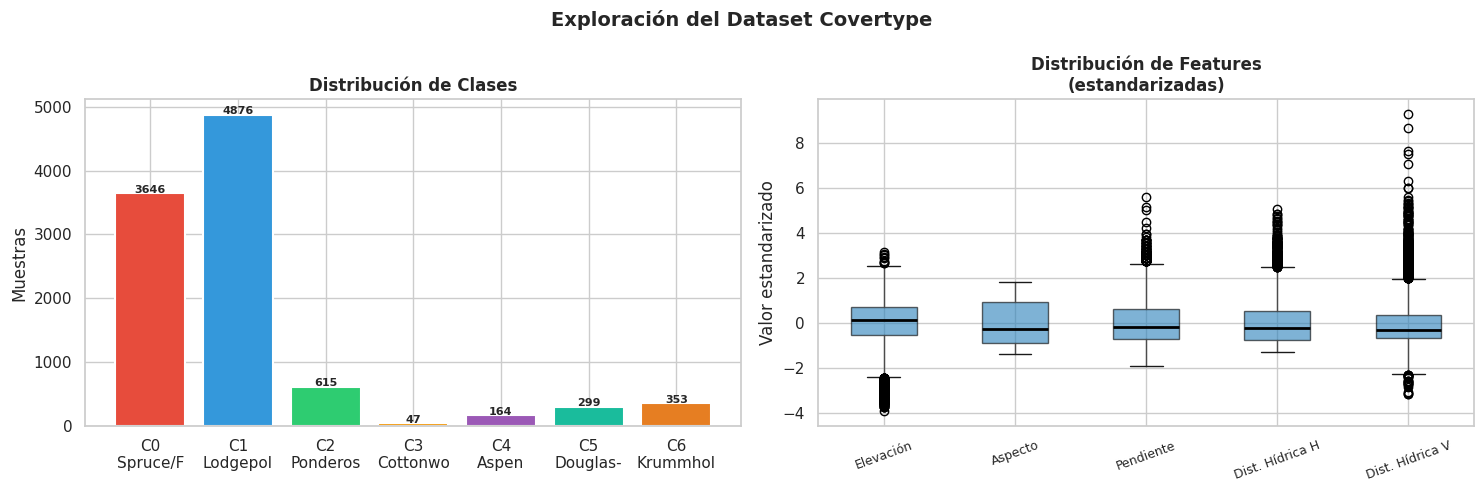

In [4]:
# Exploración visual
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Exploración del Dataset Covertype', fontsize=14, fontweight='bold')

# Distribución de clases
conteos  = y.value_counts().sort_index()
colores7 = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']
bars = axes[0].bar(
    [f'C{i}\n{CLASES[i][:8]}' for i in conteos.index],
    conteos.values,
    color=colores7, edgecolor='white', linewidth=1.5
)
axes[0].set_title('Distribución de Clases', fontweight='bold')
axes[0].set_ylabel('Muestras')
for bar, val in zip(bars, conteos.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3, str(val),
                 ha='center', fontsize=8, fontweight='bold')

# Boxplot de las 5 features más informativas
top_features = ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4']
feat_labels  = ['Elevación', 'Aspecto', 'Pendiente', 'Dist. Hídrica H', 'Dist. Hídrica V']
X_norm = (X[top_features] - X[top_features].mean()) / X[top_features].std()
X_norm.columns = feat_labels
X_norm.boxplot(ax=axes[1], patch_artist=True,
               boxprops=dict(facecolor='#2980b9', alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Distribución de Features\n(estandarizadas)', fontweight='bold')
axes[1].set_ylabel('Valor estandarizado')
axes[1].tick_params(axis='x', rotation=20, labelsize=9)

plt.tight_layout()
plt.show()

## 3. División de Datos

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f'Train : {X_train.shape[0]} muestras  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape[0]}  muestras  ({X_test.shape[0]/len(X)*100:.0f}%)')

Train : 8000 muestras  (80%)
Test  : 2000  muestras  (20%)


## 4. Random Forest

Ensemble **paralelo** que construye árboles independientes sobre bootstrap samples, seleccionando aleatoriamente un subconjunto de features en cada división.

In [8]:
print('Entrenando Random Forest...')
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',     # √(n_features) por nodo
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=SEED
)
rf.fit(X_train, y_train)
time_rf = time.time() - t0

y_pred_rf = rf.predict(X_test)

acc_rf  = accuracy_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf, average='weighted')
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf  = recall_score(y_test, y_pred_rf, average='weighted')

cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rf = cross_val_score(rf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print(f'Entrenado en {time_rf:.2f} s')
print()
print('RANDOM FOREST — Resultados')
print('=' * 55)
print(f'   Accuracy  (test)    : {acc_rf:.4f}  ({acc_rf*100:.2f}%)')
print(f'   F1-Score  (test)    : {f1_rf:.4f}')
print(f'   CV Accuracy (5-fold): {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')
print(f'   OOB Score           : {rf.oob_score_:.4f}')
print(f'   Tiempo entrenamiento: {time_rf:.2f} s')
print()
print(classification_report(y_test, y_pred_rf, target_names=CLASES, digits=4))

Entrenando Random Forest...
Entrenado en 6.40 s

RANDOM FOREST — Resultados
   Accuracy  (test)    : 0.7905  (79.05%)
   F1-Score  (test)    : 0.7811
   CV Accuracy (5-fold): 0.7888 ± 0.0064
   OOB Score           : 0.7834
   Tiempo entrenamiento: 6.40 s

                precision    recall  f1-score   support

    Spruce/Fir     0.7898    0.7833    0.7865       729
Lodgepole Pine     0.8008    0.8533    0.8262       975
Ponderosa Pine     0.6937    0.9024    0.7845       123
    Cottonwood     0.6667    0.2222    0.3333         9
         Aspen     0.8571    0.1818    0.3000        33
   Douglas-fir     0.7647    0.2167    0.3377        60
     Krummholz     0.9020    0.6479    0.7541        71

      accuracy                         0.7905      2000
     macro avg     0.7821    0.5439    0.5889      2000
  weighted avg     0.7930    0.7905    0.7811      2000



## 5. XGBoost

Ensemble **secuencial** que construye árboles de forma iterativa, donde cada árbol corrige los errores del anterior usando el gradiente de la función de pérdida.

In [9]:
print('Entrenando XGBoost...')
t0 = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_alpha=0.1,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=SEED,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
time_xgb = time.time() - t0

y_pred_xgb = xgb_model.predict(X_test)

acc_xgb  = accuracy_score(y_test, y_pred_xgb)
f1_xgb   = f1_score(y_test, y_pred_xgb, average='weighted')
prec_xgb = precision_score(y_test, y_pred_xgb, average='weighted')
rec_xgb  = recall_score(y_test, y_pred_xgb, average='weighted')

cv_xgb = cross_val_score(xgb_model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print(f'Entrenado en {time_xgb:.2f} s')
print()
print('XGBOOST — Resultados')
print('=' * 55)
print(f'   Accuracy  (test)    : {acc_xgb:.4f}  ({acc_xgb*100:.2f}%)')
print(f'   F1-Score  (test)    : {f1_xgb:.4f}')
print(f'   CV Accuracy (5-fold): {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}')
print(f'   Tiempo entrenamiento: {time_xgb:.2f} s')
print()
print(classification_report(y_test, y_pred_xgb, target_names=CLASES, digits=4))

Entrenando XGBoost...
Entrenado en 6.24 s

XGBOOST — Resultados
   Accuracy  (test)    : 0.7850  (78.50%)
   F1-Score  (test)    : 0.7805
   CV Accuracy (5-fold): 0.7949 ± 0.0066
   Tiempo entrenamiento: 6.24 s

                precision    recall  f1-score   support

    Spruce/Fir     0.7799    0.7778    0.7788       729
Lodgepole Pine     0.8004    0.8431    0.8212       975
Ponderosa Pine     0.7164    0.7805    0.7471       123
    Cottonwood     0.5000    0.4444    0.4706         9
         Aspen     0.6667    0.3030    0.4167        33
   Douglas-fir     0.7000    0.3500    0.4667        60
     Krummholz     0.8475    0.7042    0.7692        71

      accuracy                         0.7850      2000
     macro avg     0.7158    0.6004    0.6386      2000
  weighted avg     0.7829    0.7850    0.7805      2000



## 6. Curva de Pérdida XGBoost (Log Loss por iteración)

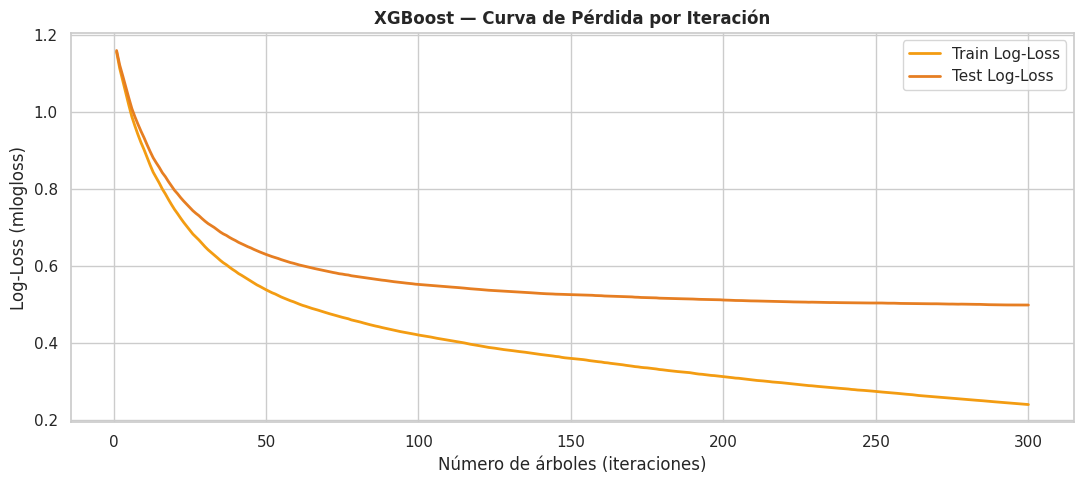

Si Train baja pero Test sube → overfitting. Aquí buscamos convergencia paralela.


In [10]:
# Re-entrenamos con evals_result para capturar la curva
evals_result = {}
xgb_curve = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', n_jobs=-1, random_state=SEED, verbosity=0
)
xgb_curve.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)
results = xgb_curve.evals_result()

plt.figure(figsize=(11, 5))
iter_range = range(1, len(results['validation_0']['mlogloss']) + 1)
plt.plot(iter_range, results['validation_0']['mlogloss'],
         color='#f39c12', lw=2, label='Train Log-Loss')
plt.plot(iter_range, results['validation_1']['mlogloss'],
         color=COLOR_XGB, lw=2, label='Test Log-Loss')
plt.xlabel('Número de árboles (iteraciones)')
plt.ylabel('Log-Loss (mlogloss)')
plt.title('XGBoost — Curva de Pérdida por Iteración', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
print('Si Train baja pero Test sube → overfitting. Aquí buscamos convergencia paralela.')

## 7. Importancia de Features

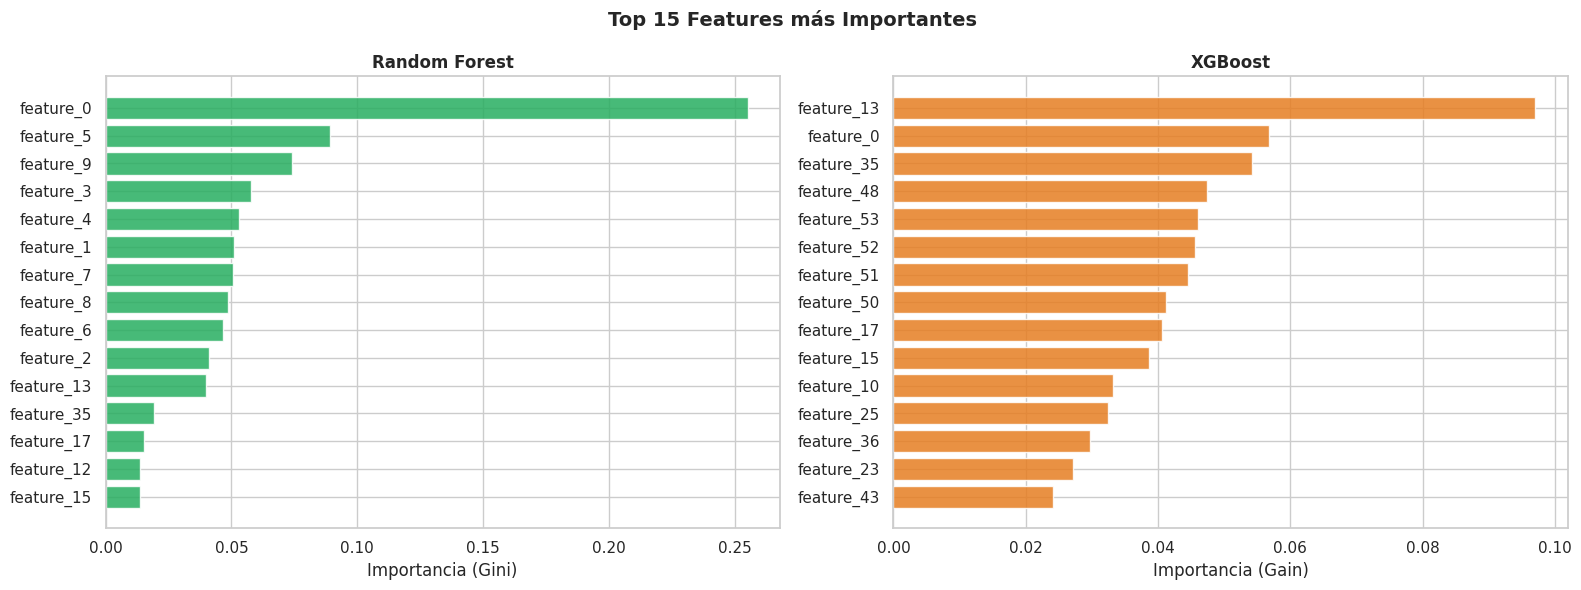


 Features relevantes para ambos modelos (5): ['feature_0', 'feature_13', 'feature_15', 'feature_17', 'feature_35']


In [11]:
TOP_N = 15
feature_names = X.columns.tolist()

# Random Forest
imp_rf  = pd.Series(rf.feature_importances_, index=feature_names)
top_rf  = imp_rf.nlargest(TOP_N)

# XGBoost
imp_xgb = pd.Series(xgb_model.feature_importances_, index=feature_names)
top_xgb = imp_xgb.nlargest(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Top {TOP_N} Features más Importantes', fontsize=14, fontweight='bold')

# RF
axes[0].barh(top_rf.index[::-1], top_rf.values[::-1], color=COLOR_RF, alpha=0.85, edgecolor='white')
axes[0].set_title('Random Forest', fontweight='bold')
axes[0].set_xlabel('Importancia (Gini)')

# XGBoost
axes[1].barh(top_xgb.index[::-1], top_xgb.values[::-1], color=COLOR_XGB, alpha=0.85, edgecolor='white')
axes[1].set_title('XGBoost', fontweight='bold')
axes[1].set_xlabel('Importancia (Gain)')

plt.tight_layout()
plt.show()

# Features en común
comunes = set(top_rf.index) & set(top_xgb.index)
print(f'\n Features relevantes para ambos modelos ({len(comunes)}): {sorted(comunes)}')

## 8. Curvas de Aprendizaje

⏳ Calculando curvas de aprendizaje (puede tardar ~1 min)...


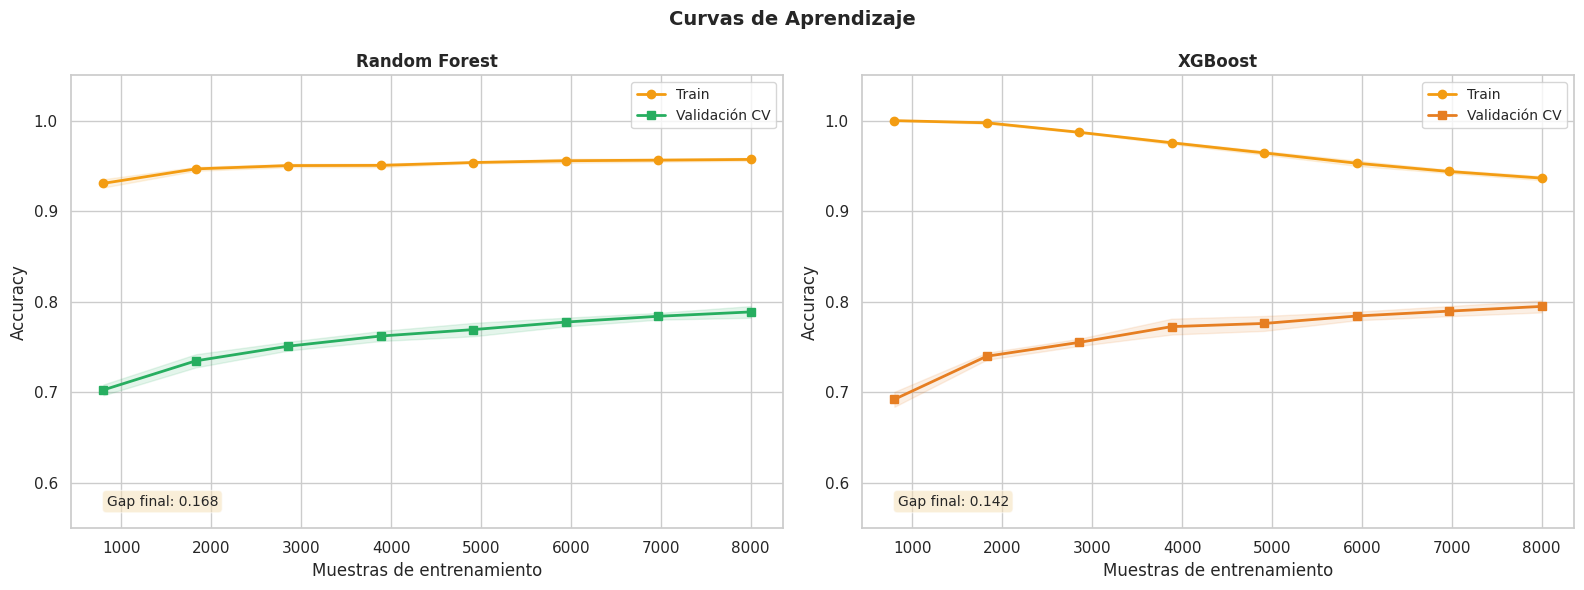

In [12]:
def plot_lc(model, titulo, color, ax):
    sizes, tr_sc, te_sc = learning_curve(
        model, X, y,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        train_sizes=np.linspace(0.10, 1.0, 8),
        scoring='accuracy', n_jobs=-1
    )
    tr_m, tr_s = tr_sc.mean(1), tr_sc.std(1)
    te_m, te_s = te_sc.mean(1), te_sc.std(1)

    ax.plot(sizes, tr_m, 'o-', color='#f39c12', lw=2, label='Train')
    ax.fill_between(sizes, tr_m-tr_s, tr_m+tr_s, alpha=0.12, color='#f39c12')
    ax.plot(sizes, te_m, 's-', color=color, lw=2, label='Validación CV')
    ax.fill_between(sizes, te_m-te_s, te_m+te_s, alpha=0.12, color=color)
    ax.set_title(titulo, fontweight='bold', fontsize=12)
    ax.set_xlabel('Muestras de entrenamiento')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.55, 1.05)
    ax.legend(fontsize=10)
    gap = tr_m[-1] - te_m[-1]
    ax.text(0.05, 0.05, f'Gap final: {gap:.3f}',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

print('Calculando curvas de aprendizaje (puede tardar ~1 min)...')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Curvas de Aprendizaje', fontsize=14, fontweight='bold')

plot_lc(rf,        'Random Forest',  COLOR_RF,  ax1)
plot_lc(xgb_model, 'XGBoost',        COLOR_XGB, ax2)

plt.tight_layout()
plt.show()

## 9. Matrices de Confusión

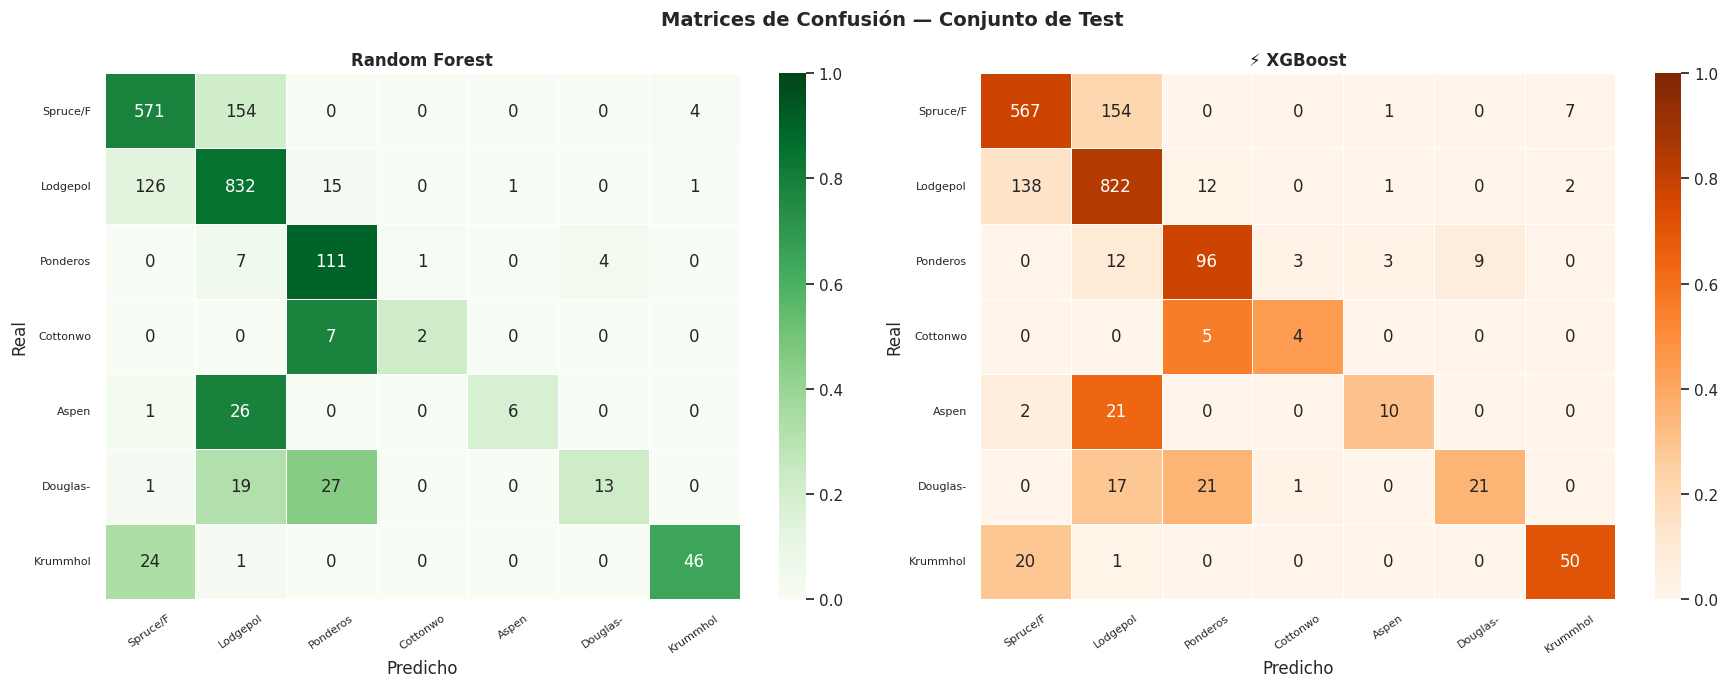

Los números son conteos; el color muestra la tasa de acierto por clase (más oscuro = mejor).


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matrices de Confusión — Conjunto de Test', fontsize=14, fontweight='bold')

for ax, y_pred, titulo, cmap in zip(
    axes,
    [y_pred_rf, y_pred_xgb],
    ['Random Forest', '⚡ XGBoost'],
    ['Greens', 'Oranges']
):
    cm = confusion_matrix(y_test, y_pred)
    # Normalizar por fila para ver % de aciertos por clase
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=cm, fmt='d', cmap=cmap, ax=ax,
        xticklabels=[c[:8] for c in CLASES],
        yticklabels=[c[:8] for c in CLASES],
        linewidths=0.4, linecolor='white',
        vmin=0, vmax=1
    )
    ax.set_title(titulo, fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.show()
print('Los números son conteos; el color muestra la tasa de acierto por clase (más oscuro = mejor).')

## 10. Tabla Comparativa Final

In [14]:
metricas_nombres = ['Accuracy', 'Precision (weighted)', 'Recall (weighted)',
                    'F1-Score (weighted)', 'CV Mean (5-fold)', 'CV Std', 'Tiempo (s)']

vals_rf  = [acc_rf,  prec_rf,  rec_rf,  f1_rf,  cv_rf.mean(),  cv_rf.std(),  time_rf]
vals_xgb = [acc_xgb, prec_xgb, rec_xgb, f1_xgb, cv_xgb.mean(), cv_xgb.std(), time_xgb]

df_comp = pd.DataFrame({
    'Métrica'       : metricas_nombres,
    'Random Forest' : vals_rf,
    'XGBoost'       : vals_xgb,
    'Δ (XGB − RF)'  : [x - r for x, r in zip(vals_xgb, vals_rf)]
}).set_index('Métrica')

df_fmt = pd.DataFrame({
    'Random Forest' : [f'{v:.4f}' for v in vals_rf],
    'XGBoost'       : [f'{v:.4f}' for v in vals_xgb],
    'Δ (XGB − RF)'  : [f'{x-r:+.4f}' for x, r in zip(vals_xgb, vals_rf)]
}, index=metricas_nombres)

print('\nTABLA COMPARATIVA COMPLETA')
print('=' * 65)
print(df_fmt.to_string())
print('=' * 65)


TABLA COMPARATIVA COMPLETA
                     Random Forest XGBoost Δ (XGB − RF)
Accuracy                    0.7905  0.7850      -0.0055
Precision (weighted)        0.7930  0.7829      -0.0101
Recall (weighted)           0.7905  0.7850      -0.0055
F1-Score (weighted)         0.7811  0.7805      -0.0006
CV Mean (5-fold)            0.7888  0.7949      +0.0061
CV Std                      0.0064  0.0066      +0.0002
Tiempo (s)                  6.4019  6.2375      -0.1644


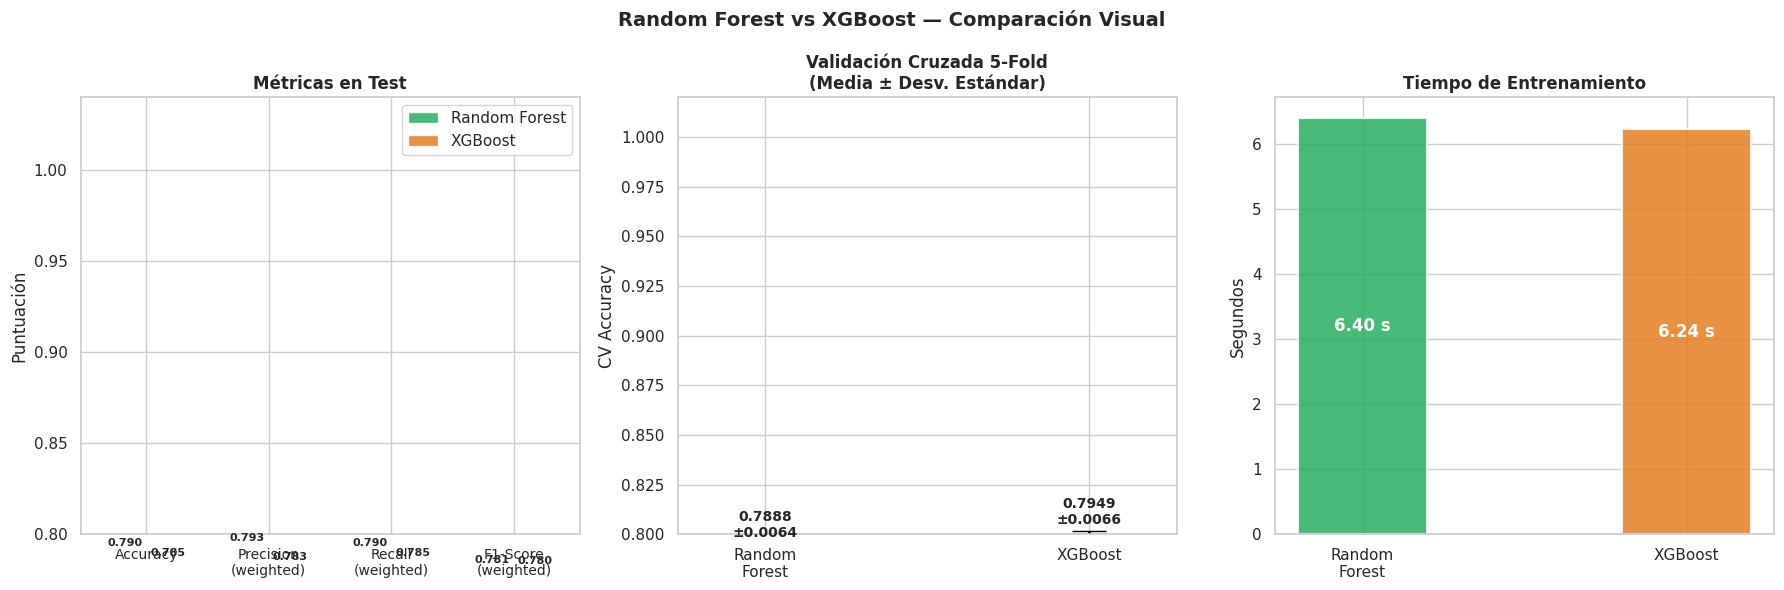

In [15]:
# ── Panel visual completo ─────────────────────────────────
metricas_plot = ['Accuracy', 'Precision\n(weighted)', 'Recall\n(weighted)', 'F1-Score\n(weighted)']
vals_rf_plot  = [acc_rf,  prec_rf,  rec_rf,  f1_rf]
vals_xgb_plot = [acc_xgb, prec_xgb, rec_xgb, f1_xgb]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Random Forest vs XGBoost — Comparación Visual',
             fontsize=14, fontweight='bold')

# ─ Barras de métricas ─
x = np.arange(len(metricas_plot))
w = 0.35
b1 = axes[0].bar(x - w/2, vals_rf_plot,  w, label='Random Forest',
                 color=COLOR_RF,  alpha=0.85, edgecolor='white')
b2 = axes[0].bar(x + w/2, vals_xgb_plot, w, label='XGBoost',
                 color=COLOR_XGB, alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas_plot, fontsize=10)
axes[0].set_ylim(0.80, 1.04)
axes[0].set_title('Métricas en Test', fontweight='bold')
axes[0].set_ylabel('Puntuación')
axes[0].legend()
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

# ─ Validación cruzada ─
nombres_cv  = ['Random\nForest', 'XGBoost']
means_cv    = [cv_rf.mean(),  cv_xgb.mean()]
stds_cv     = [cv_rf.std(),   cv_xgb.std()]
bars_cv = axes[1].bar(nombres_cv, means_cv, color=[COLOR_RF, COLOR_XGB],
                      alpha=0.85, edgecolor='white', linewidth=1.5, width=0.4)
axes[1].errorbar(nombres_cv, means_cv, yerr=stds_cv,
                 fmt='none', color='black', capsize=12, linewidth=2)
axes[1].set_ylim(0.80, 1.02)
axes[1].set_title('Validación Cruzada 5-Fold\n(Media ± Desv. Estándar)', fontweight='bold')
axes[1].set_ylabel('CV Accuracy')
for bar, m, s in zip(bars_cv, means_cv, stds_cv):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 m + s + 0.002,
                 f'{m:.4f}\n±{s:.4f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# ─ Tiempo de entrenamiento ─
bars_t = axes[2].bar(['Random\nForest', 'XGBoost'], [time_rf, time_xgb],
                     color=[COLOR_RF, COLOR_XGB], alpha=0.85,
                     edgecolor='white', linewidth=1.5, width=0.4)
axes[2].set_title('Tiempo de Entrenamiento', fontweight='bold')
axes[2].set_ylabel('Segundos')
for bar, t in zip(bars_t, [time_rf, time_xgb]):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() * 0.5,
                 f'{t:.2f} s',
                 ha='center', va='center', fontsize=12,
                 fontweight='bold', color='white')

plt.tight_layout()
plt.show()

## 11. Conclusión: ¿Cuál es el mejor?

In [16]:
# Veredicto por F1-Score
if f1_xgb > f1_rf:
    ganador, perdedor = 'XGBoost ', 'Random Forest'
    g_f1, p_f1 = f1_xgb, f1_rf
    g_acc, p_acc = acc_xgb, acc_rf
    g_cv, p_cv = cv_xgb.mean(), cv_rf.mean()
    g_t, p_t = time_xgb, time_rf
else:
    ganador, perdedor = 'Random Forest ', 'XGBoost'
    g_f1, p_f1 = f1_rf, f1_xgb
    g_acc, p_acc = acc_rf, acc_xgb
    g_cv, p_cv = cv_rf.mean(), cv_xgb.mean()
    g_t, p_t = time_rf, time_xgb

mejora_f1  = abs(g_f1  - p_f1)  / p_f1  * 100
mejora_acc = abs(g_acc - p_acc) / p_acc * 100
mejora_cv  = abs(g_cv  - p_cv)  / p_cv  * 100

print()
print('╔' + '═'*62 + '╗')
print(f'║  GANADOR: {ganador:<48}║')
print('╠' + '═'*62 + '╣')
print(f'║  Métrica              Random Forest   XGBoost          ║')
print('║' + '─'*62 + '║')
print(f'║  Accuracy (test)      {acc_rf:.4f}         {acc_xgb:.4f}          ║')
print(f'║  F1-Score (test)      {f1_rf:.4f}         {f1_xgb:.4f}          ║')
print(f'║  CV Accuracy          {cv_rf.mean():.4f}±{cv_rf.std():.4f}   {cv_xgb.mean():.4f}±{cv_xgb.std():.4f}  ║')
print(f'║  Tiempo entrenamiento {time_rf:>6.2f} s         {time_xgb:>6.2f} s         ║')
print(f'║  OOB Score            {rf.oob_score_:.4f}         N/A              ║')
print('╠' + '═'*62 + '╣')
print(f'║  DIFERENCIA en F1:    +{mejora_f1:.2f}% a favor de {ganador:<20}║')
print('╠' + '═'*62 + '╣')
print('║  CUÁNDO USAR CADA UNO:                                   ║')
print('║                                                           ║')
print('║  Random Forest:                                       ║')
print('║     Quieres entrenamiento rápido                      ║')
print('║     El dataset tiene mucho ruido o outliers           ║')
print('║     Necesitas OOB score (validación sin test set)     ║')
print('║     Quieres robustez con mínima configuración         ║')
print('║                                                           ║')
print('║  XGBoost:                                             ║')
print('║     Quieres máxima precisión predictiva               ║')
print('║     Tienes tiempo para ajustar hiperparámetros        ║')
print('║     El dataset es tabular y estructurado              ║')
print('║     Es la solución estándar en competencias ML        ║')
print('╚' + '═'*62 + '╝')


╔══════════════════════════════════════════════════════════════╗
║  GANADOR: Random Forest                                   ║
╠══════════════════════════════════════════════════════════════╣
║  Métrica              Random Forest   XGBoost          ║
║──────────────────────────────────────────────────────────────║
║  Accuracy (test)      0.7905         0.7850          ║
║  F1-Score (test)      0.7811         0.7805          ║
║  CV Accuracy          0.7888±0.0064   0.7949±0.0066  ║
║  Tiempo entrenamiento   6.40 s           6.24 s         ║
║  OOB Score            0.7834         N/A              ║
╠══════════════════════════════════════════════════════════════╣
║  DIFERENCIA en F1:    +0.08% a favor de Random Forest       ║
╠══════════════════════════════════════════════════════════════╣
║  CUÁNDO USAR CADA UNO:                                   ║
║                                                           ║
║  Random Forest:                                       ║
║     Quieres entre

## 📚 Resumen Conceptual Final

| Aspecto | Random Forest | XGBoost |
|---------|--------------|----------|
| **Tipo ensemble** | Bagging (paralelo) | Boosting (secuencial) |
| **Reduce** | Varianza | Sesgo **y** varianza |
| **Velocidad** | Rápido ✅ | Más lento |
| **Precisión** | Alta | Muy alta ✅ |
| **Regularización** | Implícita (bootstrap) | Explícita (L1/L2/γ) |
| **Hiperparámetros** | Pocos | Muchos |
| **Overfitting** | Muy resistente ✅ | Moderado (controlar con `n_estimators` + `lr`) |
| **Interpretabilidad** | Media | Media |
| **Uso típico** | Baseline sólido, datos ruidosos | Kaggle, producción de alta exigencia |

> **Regla práctica:**  
> Empieza con **Random Forest** como baseline robusto. Si necesitas más precisión y tienes tiempo para ajustar hiperparámetros → usa **XGBoost**. En la mayoría de benchmarks de datos tabulares, XGBoost gana por un margen pequeño pero consistente.
